**import all necessary libraries**

In [1]:
import sqlite3 #to read db 
import pandas as pd #for eda dataframe
import numpy as np #for eda statistical computing
import matplotlib.pyplot as plt #for plotting charts
import seaborn as sns  #for plotting charts 

**set up database folder path**

In [2]:
database = "data/gas_monitoring.db"

# conclusion: to provide a path to the .db file for connection of database for eda

**connect database**

In [3]:
conn = sqlite3.connect(database)

# conclusion: connecting to .db file

**convert db to table**

In [4]:
sql_query = "SELECT name FROM sqlite_master WHERE type='table';" #filter tables in .db file
table = pd.read_sql(sql_query, conn) #execute sql_query
table #displaying available table

# conclusion: retrieving available/possible tables from .db and converting into a table 

,name
0,gas_monitoring


**read table**

In [5]:
table_name = "gas_monitoring" #stores table name as variable 
df = pd.read_sql(f"SELECT * FROM {table_name};", conn) #execute sql query and store in df

df.head() #print first 5 values of df

# conclusion: able to see a rough gauge/range of the different attributess 

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.49,571.09,478.55,735.85,497.59,565.05,medium,7241,off,very_dim,Low Activity
1,morning,19.66,53.69,126.34,575.79,491.96,740.28,NaN,557.08,low,7241,ventilation_only,bright,Low Activity
2,night,20.95,54.12,119.34,556.53,437.50,718.34,NaN,612.62,medium,9385,off,None,Low Activity
3,morning,20.10,50.48,113.50,NaN,515.14,744.02,676.15,600.22,low,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.77,613.65,535.66,770.27,720.27,625.73,low,7241,Heating_active,moderate,Low Activity


**exploration of data**

In [6]:
df.shape # find out the how many rows and columns are in the dataset

# conclusion: 10000 rows with 14 attributes 

(10000, 14)

In [7]:
df.dtypes # find out the types of data, whether int, float etc 

# conclusion: data types are with decimal places, whole number and categorical 

Time of Day                   object
Temperature                  float64
Humidity                     float64
CO2_InfraredSensor           float64
CO2_ElectroChemicalSensor    float64
MetalOxideSensor_Unit1       float64
MetalOxideSensor_Unit2       float64
MetalOxideSensor_Unit3       float64
MetalOxideSensor_Unit4       float64
CO_GasSensor                  object
Session ID                     int64
HVAC Operation Mode           object
Ambient Light Level           object
Activity Level                object
dtype: object

In [8]:
df.isna().any() # checking if there are any null values

# conclusion: 4 attribute with null values that need to be address

Time of Day                  False
Temperature                  False
Humidity                     False
CO2_InfraredSensor           False
CO2_ElectroChemicalSensor     True
MetalOxideSensor_Unit1       False
MetalOxideSensor_Unit2       False
MetalOxideSensor_Unit3        True
MetalOxideSensor_Unit4       False
CO_GasSensor                  True
Session ID                   False
HVAC Operation Mode          False
Ambient Light Level           True
Activity Level               False
dtype: bool

In [9]:
df.isnull().sum() # check where the null values appear

# conclusion: to know how many null values arae in each of the attributes

Time of Day                     0
Temperature                     0
Humidity                        0
CO2_InfraredSensor              0
CO2_ElectroChemicalSensor     706
MetalOxideSensor_Unit1          0
MetalOxideSensor_Unit2          0
MetalOxideSensor_Unit3       2566
MetalOxideSensor_Unit4          0
CO_GasSensor                 1369
Session ID                      0
HVAC Operation Mode             0
Ambient Light Level          2532
Activity Level                  0
dtype: int64

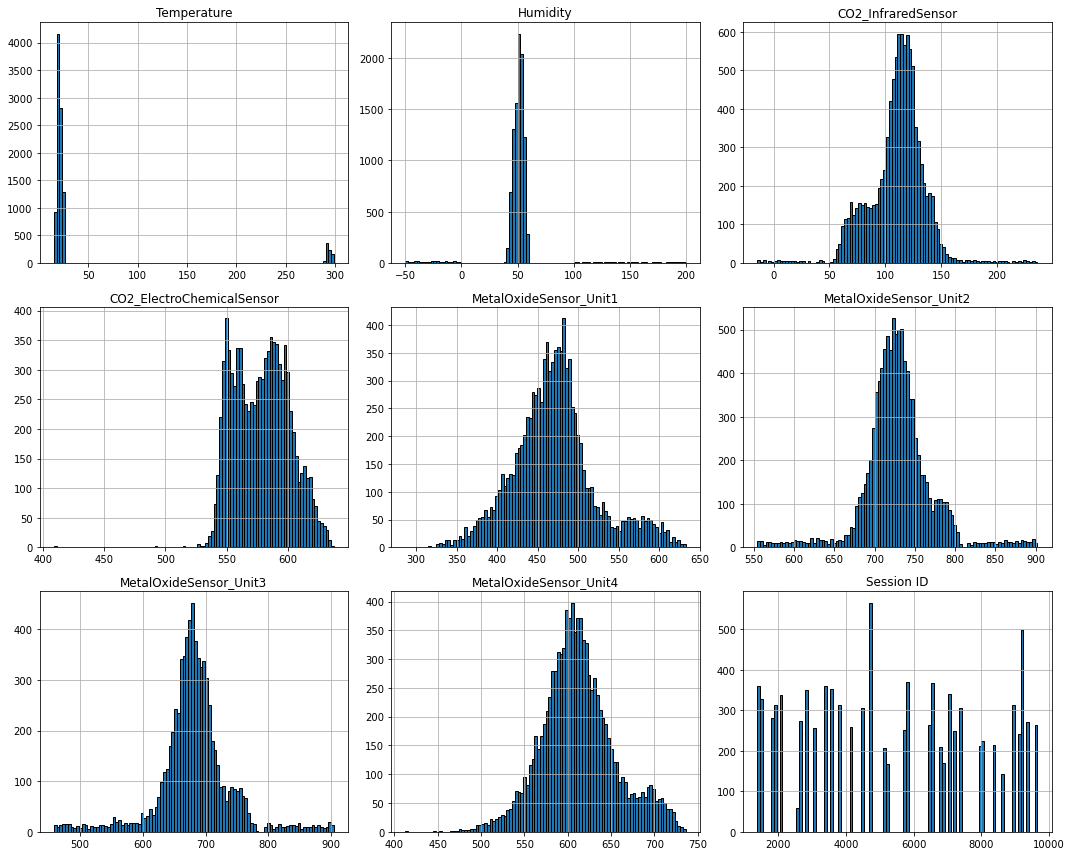

In [10]:
# check for distribution of data
df.hist(figsize=(15, 12), bins=100, edgecolor='black') #creating the histogram
plt.tight_layout() 
plt.show()

# conclusion: able to see where are the outliers 

In [11]:
df.duplicated().sum() # check for any duplicates

# conclusion: there are 120 duplicates that need to be address

120

In [12]:
df[df.duplicated()] # view duplicates

# conclusion: to see the duplicates that have been identified

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
587,afternoon,18.40,52.92,105.40,593.77,502.01,752.28,711.66,651.27,low,9658,ventilation_only,very_bright,Low Activity
598,night,20.21,54.76,126.95,543.23,454.47,677.38,625.81,542.72,high,7058,ventilation_only,None,Low Activity
1108,morning,18.80,51.59,105.10,614.08,514.43,763.02,716.54,638.28,low,5693,heating_active,bright,Moderate Activity
1154,morning,17.90,44.69,64.59,628.18,589.80,790.02,765.73,707.14,extremely low,5693,eco_mode,bright,Moderate Activity
1567,evening,23.54,44.36,124.89,592.95,444.00,725.08,691.84,603.08,low,2105,heating_active,bright,Moderate Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9650,evening,295.78,46.11,123.05,583.77,463.88,735.57,681.83,628.55,low,1374,heating_active,bright,Moderate Activity
9795,night,20.59,52.05,98.06,562.11,472.63,750.75,699.09,641.10,low,9241,heating_active,bright,High Activity
9862,afternoon,19.77,55.03,107.39,568.74,361.57,716.14,666.87,599.46,low,9385,heating_active,very_bright,Low Activity
9904,morning,19.38,57.11,111.32,597.05,464.89,732.61,684.71,605.84,medium,7241,eco_mode,bright,Low Activity


In [13]:
df.describe().T # understanding dataset to see if there are any data that are incorrect or impossible

# conclusion: can see that temperature and humidity have values that might be incorect as humidity should not be negatiive at all times, even 0% is also a rare occurrence. 

,count,mean,std,min,25%,50%,75%,max
Temperature,10000.0,42.564132,74.350143,14.94,19.0000,20.530,23.1300,298.93
Humidity,10000.0,51.125461,20.565964,-49.66,47.6800,51.300,53.8500,199.59
CO2_InfraredSensor,10000.0,110.356504,25.056797,-14.67,99.0775,113.100,124.0225,236.01
CO2_ElectroChemicalSensor,9294.0,578.333884,22.669681,408.60,559.2250,578.890,595.1800,637.90
MetalOxideSensor_Unit1,10000.0,470.363051,51.353223,286.83,439.6300,468.810,493.9400,632.89
MetalOxideSensor_Unit2,10000.0,728.265041,43.303414,554.28,707.9575,726.635,746.4925,902.21
MetalOxideSensor_Unit3,7434.0,681.359029,59.994204,457.81,658.2225,680.085,704.4050,905.15
MetalOxideSensor_Unit4,10000.0,611.956357,42.855167,412.79,585.5550,609.005,635.4800,736.11
Session ID,10000.0,5418.640400,2588.467375,1374.00,3074.0000,5214.000,7395.0000,9658.00


In [14]:
df_nodup = df.drop_duplicates().copy() # creates a duplicated df with the duplicated roles removed

In [15]:
df_nodup.shape # find out the how many rows and columns are in the dataset after removal of duplicates

# conclusion: 120 duplicates from earlier has been removed 

(9880, 14)

In [16]:
df_nodup.duplicated().sum() # check for any duplicates after removal

# conclusion: no more duplicates 

0

In [17]:
df_nodup.isnull().sum() # check where the null values appear after removal of duplicates

# conclusion: removal of duplicates as removed some of the rows, however, null values are still present

Time of Day                     0
Temperature                     0
Humidity                        0
CO2_InfraredSensor              0
CO2_ElectroChemicalSensor     705
MetalOxideSensor_Unit1          0
MetalOxideSensor_Unit2          0
MetalOxideSensor_Unit3       2554
MetalOxideSensor_Unit4          0
CO_GasSensor                 1365
Session ID                      0
HVAC Operation Mode             0
Ambient Light Level          2519
Activity Level                  0
dtype: int64

In [18]:
df_nodup.describe().T # checking of statistical dataset again 

# conclusion: negative values / vaalues thata don't make sense are still available, to remove them. 

,count,mean,std,min,25%,50%,75%,max
Temperature,9880.0,42.799506,74.718352,14.94,18.9900,20.530,23.1300,298.93
Humidity,9880.0,51.123413,20.686215,-49.66,47.6600,51.285,53.8500,199.59
CO2_InfraredSensor,9880.0,110.334979,25.129207,-14.67,99.0300,113.060,124.0225,236.01
CO2_ElectroChemicalSensor,9175.0,578.367964,22.669115,408.60,559.2800,578.930,595.2600,637.90
MetalOxideSensor_Unit1,9880.0,470.449518,51.384743,286.83,439.7225,468.840,493.9800,632.89
MetalOxideSensor_Unit2,9880.0,728.327546,43.452912,554.28,707.9675,726.710,746.5725,902.21
MetalOxideSensor_Unit3,7326.0,681.471289,60.242382,457.81,658.4000,680.190,704.4950,905.15
MetalOxideSensor_Unit4,9880.0,612.050480,42.875480,412.79,585.6350,609.130,635.5700,736.11
Session ID,9880.0,5416.231478,2586.357049,1374.00,3074.0000,5214.000,7395.0000,9658.00


In [19]:
df_nodup.describe(include="object").T # checking of categorical dataset

# conclusion: missing values are seen in CO_GasSensor and Ambient Light Level. Need to confirm the unique values as the naming convention may be different in terms of upper and lowercase as well as underscore instead of spacing (i.e. Low Activity and cooling_active)

,count,unique,top,freq
Time of Day,9880,4,afternoon,2571
CO_GasSensor,8515,5,low,4292
HVAC Operation Mode,9880,23,cooling_active,1485
Ambient Light Level,7361,5,very_bright,2815
Activity Level,9880,6,Low Activity,5156


In [20]:
df_nodup["Time of Day"].value_counts(normalize=True) * 100 # checking each of categorical dataset

# conclusion: no further rectifications required as all values are unique. the spread of each categories area also even. 

afternoon    26.022267
evening      24.858300
morning      24.564777
night        24.554656
Name: Time of Day, dtype: float64

In [21]:
df_nodup["CO_GasSensor"].value_counts(normalize=True) * 100 # checking each of categorical dataset

# conclusion: seems like CO_GasSensor values are majority in the low or extremely low categories, which means that they are relatively safe. 

low               50.405167
medium            31.250734
extremely low     12.871403
high               4.638873
extremely high     0.833823
Name: CO_GasSensor, dtype: float64

In [22]:
df_nodup["HVAC Operation Mode"].value_counts(normalize=True) * 100 # checking each of categorical dataset

# conclusion: when checking the number of unique values, there were 23 unique values, after confirming the values, there seems to be overlap in terms of uppercase and spaces and underscore. will need to clean up the unique values. 

cooling_active      15.030364
maintenance_mode    15.010121
heating_active      14.838057
eco_mode            14.331984
ventilation_only    14.321862
off                 14.311741
COOLING_ACTIVE       1.204453
OFF                  1.072874
ECO_MODE             1.072874
Off                  1.022267
MAINTENANCE_MODE     1.022267
VENTILATION_ONLY     0.991903
HEATING_ACTIVE       0.890688
Heating_Active       0.637652
Ventilation_Only     0.536437
Maintenance_Mode     0.516194
Heating_active       0.495951
Maintenance_mode     0.495951
Eco_mode             0.485830
Eco_Mode             0.485830
Ventilation_only     0.425101
Cooling_active       0.414980
Cooling_Active       0.384615
Name: HVAC Operation Mode, dtype: float64

In [23]:
# [for HVAC Operation Mode] since all categorical columns are in lower case, convert to lowercase and remove extra spaces
df_nodup["HVAC Operation Mode"] = df_nodup["HVAC Operation Mode"].str.lower().str.strip()
df_nodup["HVAC Operation Mode"].value_counts(normalize=True) * 100

# conclusion: after the clean up, there are only 6 categories and the values are balanced across all operating modes of the  HVAC.

maintenance_mode    17.044534
cooling_active      17.034413
heating_active      16.862348
off                 16.406883
eco_mode            16.376518
ventilation_only    16.275304
Name: HVAC Operation Mode, dtype: float64

In [24]:
df_nodup["Ambient Light Level"].value_counts(normalize=True) * 100 # checking each of categorical dataset

# conclusion: bright and very_bright seems to be the most common which could mean that the data collection may be biased towards daytime collection

very_bright    38.242087
bright         29.343839
moderate       16.913463
dim             9.713354
very_dim        5.787257
Name: Ambient Light Level, dtype: float64

In [25]:
df_nodup["Activity Level"].value_counts(normalize=True) * 100 # checking each of categorical dataset

# conclusion: there are also inconsistency in the naming convention of the unique values. will need to change all to lower case and to input underscore before the capital letter of the second word and change all spacing to undersecore. 

Low Activity         52.186235
Moderate Activity    28.087045
High Activity        10.890688
ModerateActivity      3.107287
LowActivity           2.965587
Low_Activity          2.763158
Name: Activity Level, dtype: float64

In [26]:
# [for Activity Level] since all categorical columns are in lower case, convert to lowercase, remove underline and remove extra spaces
df_nodup["Activity Level"] = df_nodup["Activity Level"].str.replace(r'([a-z])([A-Z])', r'\1_\2', regex=True) #add space between capital letters
df_nodup["Activity Level"] = df_nodup["Activity Level"].str.replace(' ', '_') #replace space with underscore
df_nodup["Activity Level"] = df_nodup["Activity Level"].str.lower() #convert to lowercase
df_nodup["Activity Level"].value_counts(normalize=True) * 100

# conclusion: the most common activity level is low_activity and the values are now consistent.

low_activity         57.914980
moderate_activity    31.194332
high_activity        10.890688
Name: Activity Level, dtype: float64

In [27]:
# replace missing integer values with median
df_nodup['CO2_ElectroChemicalSensor'].fillna(df_nodup['CO2_ElectroChemicalSensor'].median(), inplace=True)
df_nodup['MetalOxideSensor_Unit3'].fillna(df_nodup['MetalOxideSensor_Unit3'].median(), inplace=True)

In [28]:
# replace missing text values with mode
df_nodup['CO_GasSensor'].fillna(df_nodup['CO_GasSensor'].mode()[0],inplace=True)
df_nodup['Ambient Light Level'].fillna(df_nodup['Ambient Light Level'].mode()[0],inplace=True)

In [29]:
# check if there are still any missing values
df_nodup.isnull().sum()

# conclusion: all null values have been filled

Time of Day                  0
Temperature                  0
Humidity                     0
CO2_InfraredSensor           0
CO2_ElectroChemicalSensor    0
MetalOxideSensor_Unit1       0
MetalOxideSensor_Unit2       0
MetalOxideSensor_Unit3       0
MetalOxideSensor_Unit4       0
CO_GasSensor                 0
Session ID                   0
HVAC Operation Mode          0
Ambient Light Level          0
Activity Level               0
dtype: int64

In [30]:
df_nodup.describe(include="object").T # checking of categorical dataset

# conclusion: the count for each of the categories have been filled and unique values cleaned 

,count,unique,top,freq
Time of Day,9880,4,afternoon,2571
CO_GasSensor,9880,5,low,5657
HVAC Operation Mode,9880,6,maintenance_mode,1684
Ambient Light Level,9880,5,very_bright,5334
Activity Level,9880,3,low_activity,5722


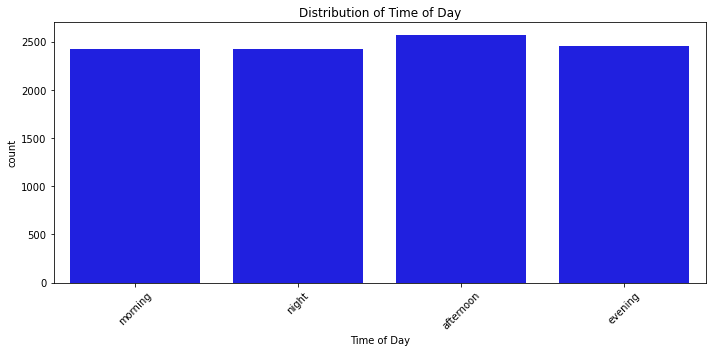

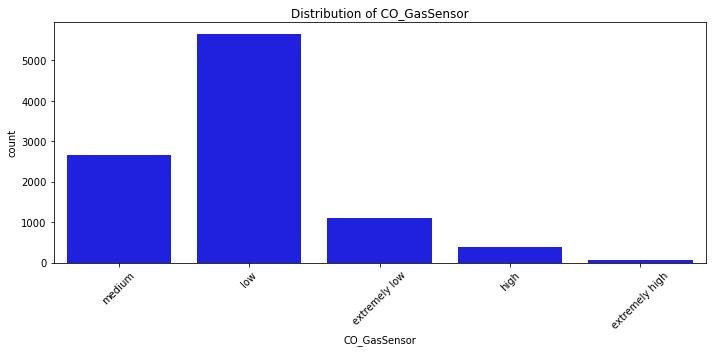

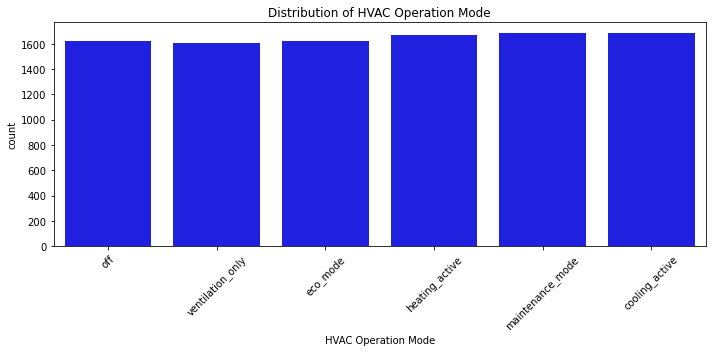

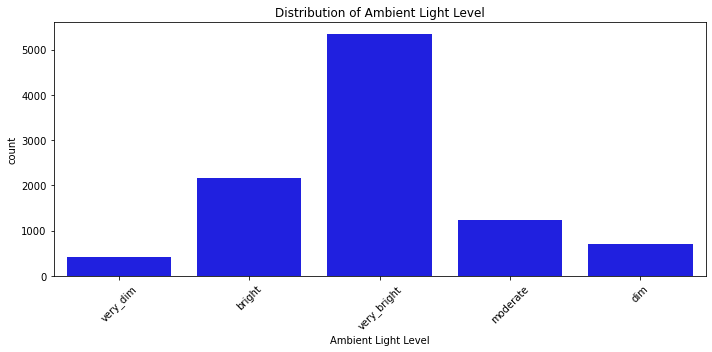

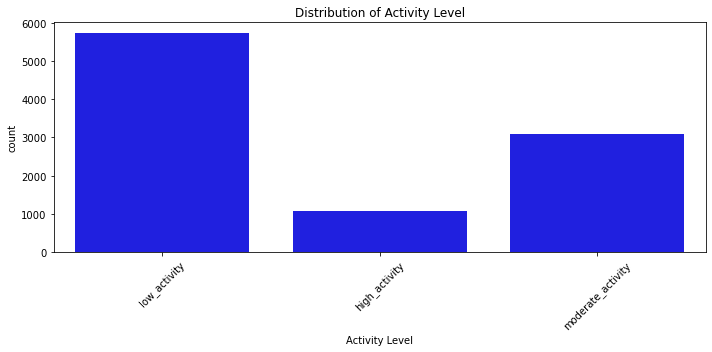

In [31]:
# plotting all categorical dataset 
categorical_cols = df_nodup.select_dtypes(include=['object']).columns
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, data=df_nodup, color='blue')
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
# conclusion:-
# time of day >> evenly distributed across morning, afternoon, evening and night. doesn't seem to have biasedness across the different time.
# CO_GasSensor >> majority of the readings are in the safe zone (extremely low, low, medium). there is class imbalance within the CO2 classification feature which will need to take into account during machine learning
# HVAC Operation Mode >> all of the mode appear in similara frequencies and is well balance.
# Ambient Light Level >> distribution is strongly uneven and is most likel a strong predictor of Activity level, to check later with correlation mapping.
# Activity Level >> distribution is imbalanced. 

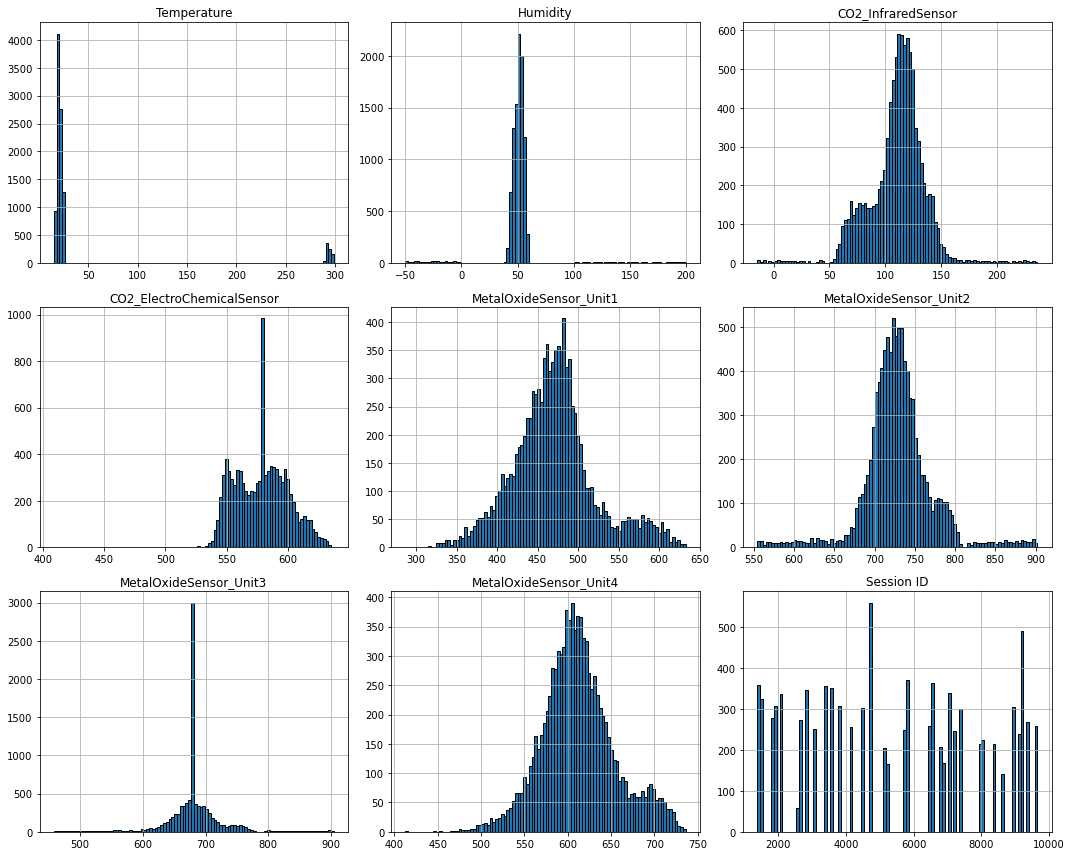

In [32]:
# checking the distribution visually for all numerical values
df_nodup.hist(figsize=(15, 12), bins=100, edgecolor='black')
plt.tight_layout()
plt.show()

# conclusion: unrealistic values exist and woulld require clean up to better improve the data

In [33]:
# narrowing values to only include realistic values
df_nodup['Temperature'] = df_nodup['Temperature'].clip(lower=10, upper=50) #temperature is usually around 10 to 50 deg
df_nodup['Humidity'] = df_nodup['Humidity'].clip(lower=0, upper=100) #humidity to keep to 0 to 100%

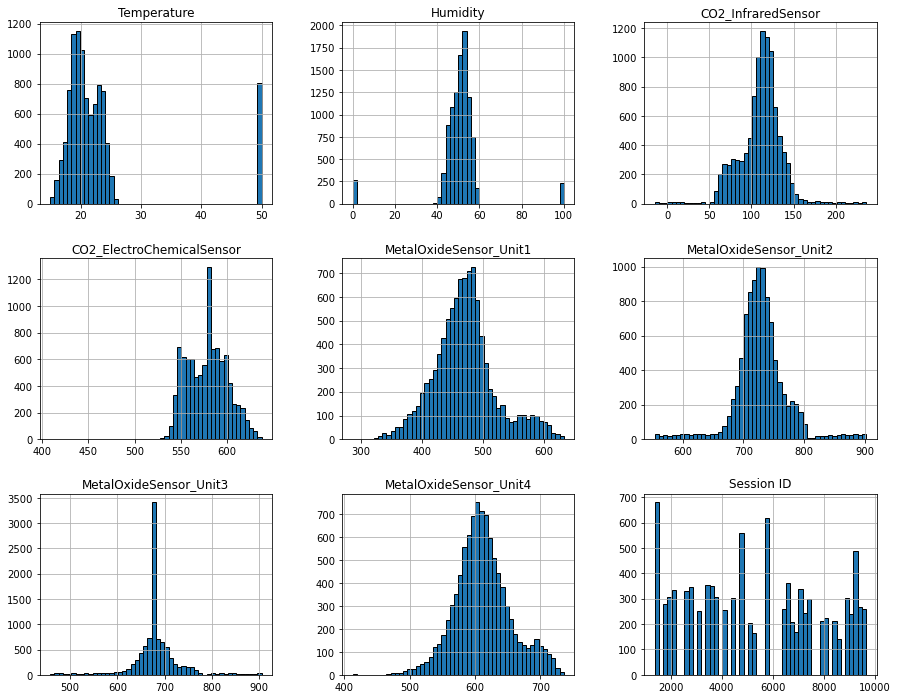

In [34]:
# checking the distribution visually for all numerical values
df_nodup.hist(figsize=(15, 12), bins=50, edgecolor='black')
plt.show()

# conclusion:-
# temperature >> distribution mostly between 20-30 with a cluster of values at 50, clipping has been done to 50 to remove unrealistic values
# humidity >> most values lie between 40-60 with extreme low and high values. 
# CO2 infrared sensor >> bell shaped curve with few values in the negative and high regions
# CO2 electrochemical sensor >> normal distriibution
# metaloxide sensors >> graph is generally smooth with no sudden spikes 
# session id >> although session ID is integer, it is not a physical measurement as it just a unique identifier for each monitoring session

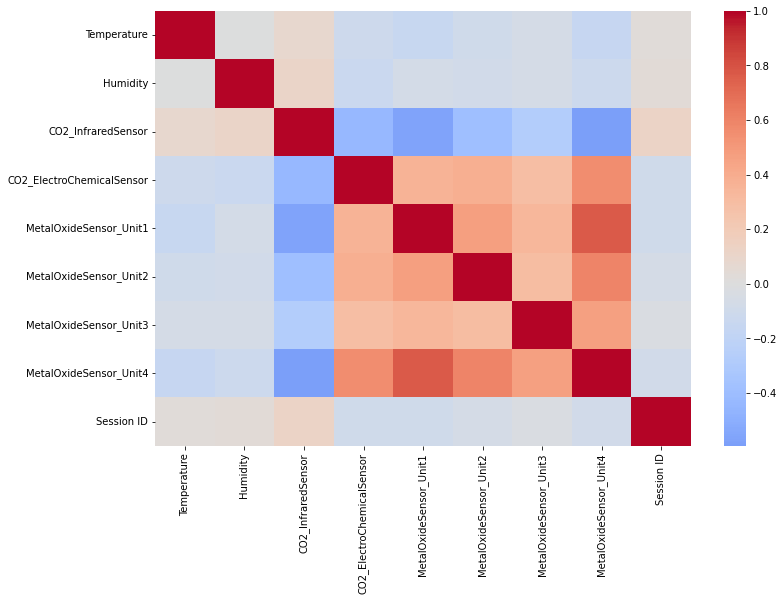

In [35]:
# plotting of correlation heatmap to see how the attributes are correlated
numeric_cols = df_nodup.select_dtypes(include=['number']).columns
plt.figure(figsize=(12,8))
sns.heatmap(df_nodup[numeric_cols].corr(), cmap="coolwarm", center=0)
plt.show()

# conclusion:-
# session id has weak correlations with all variables as it is an identifier and not a statistical value. 
# genereally strong correlations between the 4 units of metaloxide sensors, with unit 1 and unit 4 being highly correlated to each other. 
# co2 electrochemical sensors and the metaloxide sensors are moderately correlated and can mean that aif the co2 level rise, metalaoxide gas will rise as well.
# temperature and humidity has weak or no correlations with other attributes, which means that it might not be useful in predicting the activity level.

Final Conclusion

In [ ]:
# From the EDA, it was observed that there are both numberical and categorical attributes. Duplicates, null values and inconsistent naming conventions were identified and cleaned. There were also unrealistic values for the numberical attributes and have been clipped to more realistic values so that all remaining rows fall within reasonable ranges while keeping the sample size as much as possible. 
# Duplicate data: duplicated data were identified and removed to only keep one row
# Missing data: missing numerical data were filled with the median while categorical attributes were filled with the mode to ensure no biasedness in the dataset
# Target variable: the target variable - Activity Level was found to be impbalanced and wouuld need to take into consideration during the model evaluation. 
# Modelling plans: asa there are multicollinearity between sensors, can consider to use tree-based models. to target imbalance, can use f1-score for model evaluation. 